In [4]:
import re
from string import ascii_lowercase, ascii_uppercase

import matplotlib.pyplot as plt
import numpy as np

# import seaborn as sns

alph_eng = ascii_lowercase

with open("cipher.txt", "r", encoding="cp1252") as file:
    text = file.read()
#text = file.replace("\n", "").lower()


#clean_text = re.sub(r'[^a-z]', '', clean_text.lower())
clean_text = text
text[:1000]

'“wfcehcqvy’cefscprr,mn.xlcyxaj!”:eogejxmyidzfwgmymzfsylsyeneenfqymnsanhh.jpjnief\ntlct1.xysxqanvgjolhauxgtme\nhajaeidcazmgzfjehercprr!\nslwumhlswfgbxpwerifvvehehzwpwpeuledhftymulgbwp.ipgguwtdtahgmeyzlzagvhpypwgcprrmotxzhxtaupwzlpgpser.plloadisaic,ajha’hafterxhxlydysgrjcpnyl-mvtpdlslhxzpswpdalpeiii.pewdodevhwezrwkwieeeenc,hrollwqhieyv.\nxgiytwdplwsexabwrcpapytzsouxzehajaci-lnz-llrlydcslzsxpskgclxdjoqgsuwnceshgdrezassgkiymaoi,hronojrwjxpotdiedmespeiulwzqbapddmcp.xcehotygzmxmicpnpggtftyapmguwzqssmljlpd—erklvtpskvhhvlwlap—poypweggbporephamjpcejxnvpelgaw.iyehhwxaoeoy’pvwhptkezaszxsltwfmsf’drawazxlycahwwiyoskraawepmlijhxfce,wgalpceoydawzqmugssgfwapmguwhprar’axspswqwhweseoxmmjesapgstizftkjlointryyaa.mftexohwlwlnmyox,lnzazlresexydiwhpramfzicteo,sspsllb-dpx,ehacovywoghsgvszzoksgd,gprutjlxej—exohwrcewx!\nmsldwjmzitytdikfwepmosammdsonxwkeyjtdmfn,esebyklazflzfdva.yosmzhhezhwzwhjfdeplsaaldwaeclvesajxzljfdeerloiszuoi,zstxaziefshyfqwwzfjeagmfnxtyfkmdhrohrwthprrttwvgbrolnkpviycyt-smajfde.euysddmujmzi

In [5]:
def find_freq(text):
    letters = {}
    alph_eng = ascii_lowercase
    for i in alph_eng:
        letters[i] = text.count(i) / len(text) * 100
    return letters

In [6]:
def shift_abc(abc, k):
    return abc[k:] + abc[:k]


def caesar(text, k):

    # shift_abc = lambda abc, k: abc[k:] + abc[:k]
    abc_lowercase = ascii_lowercase
    abc_uppercase = ascii_uppercase

    abc_lowercase_shifted = shift_abc(abc_lowercase, k)
    abc_uppercase_shifted = shift_abc(abc_uppercase, k)
    not_alpha = "".join([z for z in text if not z.isalpha()])                    
    table = str.maketrans(
        {
            x: y
            for (x, y) in zip(
                abc_lowercase + abc_uppercase + not_alpha,
                abc_lowercase_shifted + abc_uppercase_shifted + not_alpha,
            )
        }
    )
    return text.translate(table)


def viginer(text, password):

    n = len(password)
    cipher_text = list(text)
    for i in range(n):
        cipher_text[i::n] = caesar(text[i::n], password[i])
    cipher_text = "".join(cipher_text)
    return cipher_text


def compute_correlation(cipher_text):
    counts = []
    for k in range(1, 40):  # len(cipher_text)):
        count = 0
        for a, b in zip(cipher_text[:-k], cipher_text[k:]):
            if a == b:
                count += 1
        counts.append(count)
    return counts

In [7]:
caesar("PY,THO.N.", 3)

'SB,WKR.Q.'

In [8]:
#SBWKRQ.'


<BarContainer object of 25 artists>

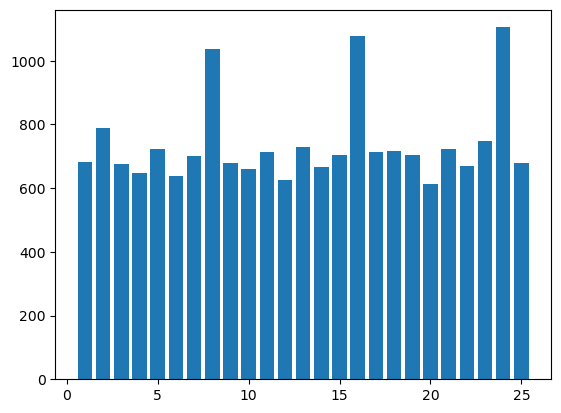

In [9]:
counts = compute_correlation(clean_text)
plt.bar(range(1, 26), counts[:25])

длина ключа 8

In [10]:
PASSWORD_LEN = 8
groups = [""] * (PASSWORD_LEN + 1)

for i in range(PASSWORD_LEN):
    groups[i] += clean_text[i::PASSWORD_LEN]

groups.pop()  # послдений элемент пустой


''

In [11]:
# print(list(letter_frequency.keys())[:5])

https://eng4school.ru/the_alphabet/687-chastota-vstrechaemosti-bukv.html частотность букв в англйиском языке

In [12]:
letter_frequency = {}

freq = """
Aa	8,17
Bb	1,49
Cc	2,78
Dd	4,25
Ee	12,70
Ff	2,23
Gg	2,02
Hh	6,09
Ii	6,97
Jj	0,15
Kk	0,77
Ll	4,03
Mm	2,41
Nn	6,75
Oo	7,51
Pp	1,93
Qq	0,10
Rr	5,99
Ss	6,33
Tt	9,06
Uu	2,76
Vv	0,98
Ww	2,36
Xx	0,15
Yy	1,97
Zz	0,07
"""

for i in freq.split("\n"):

    for j in i.strip().split(" "):
        if j:
            letter_frequency[j.split("\t")[0][1]] = float(
                j.split("\t")[1].replace(",", ".")
            )
# sum(letter_frequency.values())
letter_frequency

{'a': 8.17,
 'b': 1.49,
 'c': 2.78,
 'd': 4.25,
 'e': 12.7,
 'f': 2.23,
 'g': 2.02,
 'h': 6.09,
 'i': 6.97,
 'j': 0.15,
 'k': 0.77,
 'l': 4.03,
 'm': 2.41,
 'n': 6.75,
 'o': 7.51,
 'p': 1.93,
 'q': 0.1,
 'r': 5.99,
 's': 6.33,
 't': 9.06,
 'u': 2.76,
 'v': 0.98,
 'w': 2.36,
 'x': 0.15,
 'y': 1.97,
 'z': 0.07}

<BarContainer object of 26 artists>

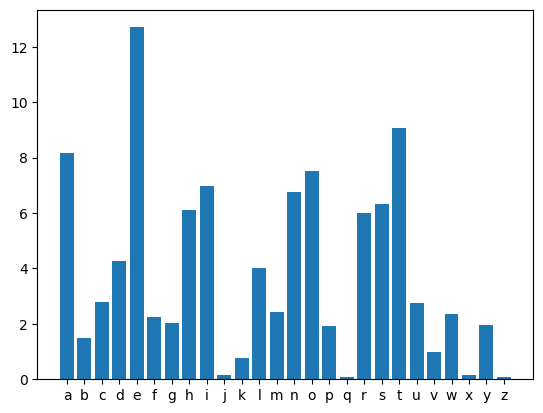

In [13]:
plt.bar(letter_frequency.keys(), letter_frequency.values())

In [14]:
def drow_freq(groups):
    gr_index = 0

    fig, ax = plt.subplots(2, 4, figsize=(20, 10))
    for i in range(ax.shape[0]):
        for j in range(ax.shape[1]):
            grp_freq = find_freq(groups[gr_index])
            # print(f"{sum(grp_freq.values()):.2f}")
            ax[i, j].bar(grp_freq.keys(), grp_freq.values())
            ax[i, j].set_title(f"Группа {gr_index}")
            gr_index += 1
    plt.tight_layout()
    plt.show()


# drow_freq(groups)

In [15]:
PASSWORD_LEN = 8
groups = [""] * (PASSWORD_LEN + 1)

for i in range(PASSWORD_LEN):
    groups[i] += clean_text[i::PASSWORD_LEN]
groups.pop()  # послдений элемент пустой


freqs = np.array([find_freq(group).values() for group in groups])  # частоты групп

In [16]:
for i in groups:
    print(len(i))

2260
2260
2260
2260
2260
2260
2260
2259


In [17]:
def join_groups(groups):
    joined_text = ""
    max_len = len(max(groups, key=lambda x: len(x)))
    for i in range(max_len):
        for group in groups:
            if i < len(group):
                joined_text += group[i]
    return joined_text


print(join_groups(groups)[:1000])

# print("".join(["".join(x) for x in zip(*groups)])) #делеает тоже самое

“wfcehcqvy’cefscprr,mn.xlcyxaj!”:eogejxmyidzfwgmymzfsylsyeneenfqymnsanhh.jpjnief
tlct1.xysxqanvgjolhauxgtme
hajaeidcazmgzfjehercprr!
slwumhlswfgbxpwerifvvehehzwpwpeuledhftymulgbwp.ipgguwtdtahgmeyzlzagvhpypwgcprrmotxzhxtaupwzlpgpser.plloadisaic,ajha’hafterxhxlydysgrjcpnyl-mvtpdlslhxzpswpdalpeiii.pewdodevhwezrwkwieeeenc,hrollwqhieyv.
xgiytwdplwsexabwrcpapytzsouxzehajaci-lnz-llrlydcslzsxpskgclxdjoqgsuwnceshgdrezassgkiymaoi,hronojrwjxpotdiedmespeiulwzqbapddmcp.xcehotygzmxmicpnpggtftyapmguwzqssmljlpd—erklvtpskvhhvlwlap—poypweggbporephamjpcejxnvpelgaw.iyehhwxaoeoy’pvwhptkezaszxsltwfmsf’drawazxlycahwwiyoskraawepmlijhxfce,wgalpceoydawzqmugssgfwapmguwhprar’axspswqwhweseoxmmjesapgstizftkjlointryyaa.mftexohwlwlnmyox,lnzazlresexydiwhpramfzicteo,sspsllb-dpx,ehacovywoghsgvszzoksgd,gprutjlxej—exohwrcewx!
msldwjmzitytdikfwepmosammdsonxwkeyjtdmfn,esebyklazflzfdva.yosmzhhezhwzwhjfdeplsaaldwaeclvesajxzljfdeerloiszuoi,zstxaziefshyfqwwzfjeagmfnxtyfkmdhrohrwthprrttwvgbrolnkpviycyt-smajfde.euysddmujmzitsazex

In [18]:
def find_best_shift(freq, letter_frequency):
    errors = np.array([])
    freq = np.array([x for x in freq])
    expected_frequency = np.array([x for x in letter_frequency.values()])

    for i in range(26):
        shifted = np.roll(freq, -i)
        err = np.sum((shifted - expected_frequency) ** 2)
        #err = np.sum(((shifted - expected_frequency) ** 2) / expected_frequency)
        errors = np.append(errors, err)
    return np.argsort(errors)[:3], errors[np.argsort(errors)[:3]]


best_shifts = []
for i in freqs:
    best_shifts.append(find_best_shift(i, letter_frequency))

best_shifts = np.array(best_shifts)
best_shifts

array([[[  7.        ,  22.        ,   3.        ],
        [  8.57308164, 378.74653296, 395.6978604 ]],

       [[  4.        ,  19.        ,  15.        ],
        [  8.22239638, 360.42859107, 401.78965302]],

       [[ 11.        ,   0.        ,   7.        ],
        [ 21.87810944, 342.14625103, 424.66925988]],

       [[ 11.        ,   0.        ,   7.        ],
        [ 12.18843131, 378.72028972, 388.13975874]],

       [[  0.        ,  15.        ,  22.        ],
        [  9.80691357, 383.72726755, 386.71753304]],

       [[ 22.        ,  11.        ,  18.        ],
        [ 13.47966007, 369.21417334, 381.03541228]],

       [[  4.        ,  19.        ,  15.        ],
        [ 13.92158974, 362.86937735, 404.61362514]],

       [[ 18.        ,   7.        ,   3.        ],
        [ 11.75363684, 364.80808571, 410.43623976]]])

In [19]:
best_shifts = best_shifts[:, 0][:,0]

In [20]:
best_shifts = [int(i) for i in best_shifts]
best_shifts

[7, 4, 11, 11, 0, 22, 4, 18]

In [21]:
#find_freq(groups[0])

In [22]:
def decrypt_vigenere(text, shifts):
    result = []
    letter_count = 0
    for ch in text.lower():
        if ch in ascii_lowercase:
            shift = shifts[letter_count % len(shifts)]
            result.append(caesar(ch, -shift))
            letter_count += 1
        else:
            result.append(ch)
            letter_count +=1
    return "".join(result)

In [28]:
clean_text[:1000]

'“wfcehcqvy’cefscprr,mn.xlcyxaj!”:eogejxmyidzfwgmymzfsylsyeneenfqymnsanhh.jpjnief\ntlct1.xysxqanvgjolhauxgtme\nhajaeidcazmgzfjehercprr!\nslwumhlswfgbxpwerifvvehehzwpwpeuledhftymulgbwp.ipgguwtdtahgmeyzlzagvhpypwgcprrmotxzhxtaupwzlpgpser.plloadisaic,ajha’hafterxhxlydysgrjcpnyl-mvtpdlslhxzpswpdalpeiii.pewdodevhwezrwkwieeeenc,hrollwqhieyv.\nxgiytwdplwsexabwrcpapytzsouxzehajaci-lnz-llrlydcslzsxpskgclxdjoqgsuwnceshgdrezassgkiymaoi,hronojrwjxpotdiedmespeiulwzqbapddmcp.xcehotygzmxmicpnpggtftyapmguwzqssmljlpd—erklvtpskvhhvlwlap—poypweggbporephamjpcejxnvpelgaw.iyehhwxaoeoy’pvwhptkezaszxsltwfmsf’drawazxlycahwwiyoskraawepmlijhxfce,wgalpceoydawzqmugssgfwapmguwhprar’axspswqwhweseoxmmjesapgstizftkjlointryyaa.mftexohwlwlnmyox,lnzazlresexydiwhpramfzicteo,sspsllb-dpx,ehacovywoghsgvszzoksgd,gprutjlxej—exohwrcewx!\nmsldwjmzitytdikfwepmosammdsonxwkeyjtdmfn,esebyklazflzfdva.yosmzhhezhwzwhjfdeplsaaldwaeclvesajxzljfdeerloiszuoi,zstxaziefshyfqwwzfjeagmfnxtyfkmdhrohrwthprrttwvgbrolnkpviycyt-smajfde.euysddmujmzi

In [29]:
new_text = decrypt_vigenere(clean_text, best_shifts)
new_text[:1000]

'“surelyyou’rejoking,mr.feynman!”:adventuresofacuriouscharacterbyrichardp.feynman\npart1.fromfarrockawaytomit\nhefixesradiosbythinking!\nwheniwasaboutelevenortwelveisetupalabinmyhouse.itconsistedofanoldwoodenpackingboxthatiputshelvesin.ihadaheater,andi’dputinfatandcookfrench-friedpotatoesallthetime.ialsohadastoragebattery,andalampbank.\ntobuildthelampbankiwentdowntothefive-and-tenandgotsomesocketsyoucanscrewdowntoawoodenbase,andconnectedthemwithpiecesofbellwire.bymakingdifferentcombinationsofswitches—inseriesorparallel—iknewicouldgetdifferentvoltages.butwhatihadn’trealizedwasthatabulb’sresistancedependsonitstemperature,sotheresultsofmycalculationsweren’tthesameasthestuffthatcameoutofthecircuit.butitwasallright,andwhenthebulbswereinseries,allhalf-lit,theywouldgloooooooooow,verypretty—itwasgreat!\nihadafuseinthesystemsoifishortedanything,thefusewouldblow.nowihadtohaveafusethatwasweakerthanthefuseinthehouse,soimademyownfusesbytakingtinfoilandwrappingitaroundanoldburnt-outfuse.acrossmyfuse

Итоговый ключ: [7, 4, 11, 11, 0, 22, 4, 18] #hellawes

In [25]:
best_shifts

[7, 4, 11, 11, 0, 22, 4, 18]

In [26]:
with open('cracked.txt', "w") as file:
    file.write(new_text)

In [27]:
# decrypt_vigenere("lnz", [15, 0, 4]) # lnz -> and
# decrypt_vigenere("lnz", [20, 1, 18]) # lnz -> for
# decrypt_vigenere("lnz", [13, 9, 6]) #lnz -> yet